# dependencies: papermill and scrapbook

In [1]:
!ls
!pip install scrapbook
!pip install papermill
!pip install adjustText

Ag_Plot_Test_Protocol.ipynb	Utils.py
MBMF_rampdown_ag14100.png	Zpdf_comparison.png
MBMF_rampdown_ag14106.png	Zpdf_comparison.zip
MBMF_rampdown_ag14112.png	Zpds_three_segments_ag14100.png
Oc_RampDown14100.png		Zpds_three_segments_ag14100.tar
Oc_RampDown14106.png		Zpds_three_segments_ag14106.png
Oc_RampDown14112.png		Zpds_three_segments_ag14112.png
Preliminary_Scurve_2025.ipynb	Zpds_threesegmentsAndWait_ag14100.png
README.txt			Zpds_threesegmentsAndWait_ag14106.png
README.txt:Zone.Identifier	Zpds_threesegmentsAndWait_ag14112.png
Ramps_ag14100.png		__pycache__
Ramps_ag14106.png		ag13628
Ramps_ag14112.png		ag14100
S_curve.png			ag14106
Summary_ag14100.png		ag14112
Summary_ag14106.png		old_Ag_Plot.ipynb
Summary_ag14112.png		old_script.ipynb
TimevsPHI_rampdown_ag14100.png	r14100.ipynb
TimevsPHI_rampdown_ag14106.png	r14106.ipynb
TimevsPHI_rampdown_ag14112.png	r14112.ipynb
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because norm

In [2]:
import papermill as pm
import scrapbook as sb
import numpy as np
from matplotlib import pyplot as plt
from adjustText import adjust_text
import pandas as pd

In [3]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable


# Get Chuckman Simulation

In [4]:
# df = pd.read_excel("../chuckman_simulation/250914_103516_vertices.xlsx")

# print(df.head())

# print(df.columns.tolist())

# typeSimulation = np.array(df['Octupole current during release (A)'].tolist())
# biases_sim = np.array(df['Trap bias (g)'])
# duration = np.array(df['Ramp duration per segment (s)'])

# segment6_up   = df['Window 6 up'].tolist()
# segment6_down = df['Window 6 down'].tolist()

# segment7_up   = df['Window 7 up'].tolist()
# segment7_down = df['Window 7 down'].tolist()

# TotUp   =  np.array(segment7_up) + np.array(segment6_up)
# TotDown =  np.array(segment7_down) + np.array(segment6_down)
# simulation    = TotDown / (TotUp + TotDown)

# TotUp   =  np.array(segment6_up)
# TotDown =  np.array(segment6_down)
# simulation_s6 = TotDown / (TotUp + TotDown)

# TotUp   =  np.array(segment7_up)
# TotDown =  np.array(segment7_down)
# simulation_s7 = TotDown / (TotUp + TotDown)

# mask = (typeSimulation == 830)

# print(mask)

# simulation_830 = simulation[mask]
# simulation_s6_830 = simulation_s6[mask]
# simulation_s7_830 = simulation_s7[mask]
# biases_sim_830 = biases_sim[mask]

# mask = (typeSimulation == 275) & (duration == 10)

# simulation_275 = simulation[mask]
# simulation_s6_275 = simulation_s6[mask]
# simulation_s7_275 = simulation_s7[mask]
# biases_sim_275 = biases_sim[mask]

# print(biases_sim_275, simulation_275)



# Dictionary to link the run at the nominal bias
# Modify this by adding manually the runs

In [5]:
# add entry here ↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓
dictRun = {"ag14100/ag14100.vertex.csv": 0,
           "ag14106/ag14106.vertex.csv": -2,
           "ag14112/ag14112.vertex.csv": -.75
          }

In [6]:
# Extract Preliminary S-curve

In [7]:
S, S_ramp1, S_ramp2, S_ramp3, S_ramp4       = [],[],[],[],[]
dS, dS_ramp1, dS_ramp2, dS_ramp3, dS_ramp4 = [],[],[],[],[]
bias = []
list_runs = []

Ntot_list, Nup_list, Ndown_list = [],[],[]

for key, bias_ in dictRun.items():
    print(key)
    pm.execute_notebook(
        'old_Ag_Plot.ipynb',
        f'{key.split("/")[0].replace("ag","r")}.ipynb',
        parameters= {"run_to_analyze" : key}
    )
    # read result
    nb = sb.read_notebook(f'{key.split("/")[0].replace("ag","r")}.ipynb')
    
    print(nb.scraps["my_result"].data)
    
    Sextr, dSextr = nb.scraps["my_result"].data[0], nb.scraps["my_result"].data[1]
    S.append(Sextr); dS.append(dSextr)

    Sextr, dSextr = nb.scraps["ramp1"].data[0], nb.scraps["ramp1"].data[1]
    S_ramp1.append(Sextr); dS_ramp1.append(dSextr)

    Sextr, dSextr = nb.scraps["ramp2"].data[0], nb.scraps["ramp2"].data[1]
    S_ramp2.append(Sextr); dS_ramp2.append(dSextr)

    Sextr, dSextr = nb.scraps["ramp3"].data[0], nb.scraps["ramp3"].data[1]
    S_ramp3.append(Sextr); dS_ramp3.append(dSextr)

    #Sextr, dSextr = nb.scraps["ramp4"].data[0], nb.scraps["ramp4"].data[1]
    #S_ramp4.append(Sextr); dS_ramp4.append(dSextr)
    
    bias.append(bias_)
    
    list_runs.append(key.split("/")[0].replace("ag","r"))

    # read all the data
    Ntot, Nup, Ndown = nb.scraps["tot_counts"].data[0], nb.scraps["tot_counts"].data[1], nb.scraps["tot_counts"].data[2]
    Ntot_list.append(Ntot)

ag14100/ag14100.vertex.csv


Executing:   0%|          | 0/19 [00:00<?, ?cell/s]

[0.9751483081977329, 0.0066228868374579595]
ag14106/ag14106.vertex.csv


Executing:   0%|          | 0/19 [00:00<?, ?cell/s]

[0.02050194810836234, 0.006491842204784499]
ag14112/ag14112.vertex.csv


Executing:   0%|          | 0/19 [00:00<?, ?cell/s]

[0.5592614548540886, 0.028084892399125108]


In [8]:
S, S_ramp1, S_ramp2, S_ramp3, S_ramp4       = np.array(S), np.array(S_ramp1), np.array(S_ramp2), np.array(S_ramp3), np.array(S_ramp4)
dS, dS_ramp1, dS_ramp2, dS_ramp3, dS_ramp4  = np.array(dS), np.array(dS_ramp1), np.array(dS_ramp2), np.array(dS_ramp3), np.array(dS_ramp4)
bias = np.array(bias)
list_runs = np.array(list_runs)

bias; S=Ndwn/(Ntot) ; dS
| 0.00g,	  0.98,	 0.0066
| -2.00g,	  0.02,	 0.0065
| -0.75g,	  0.56,	 0.028
[False False False]


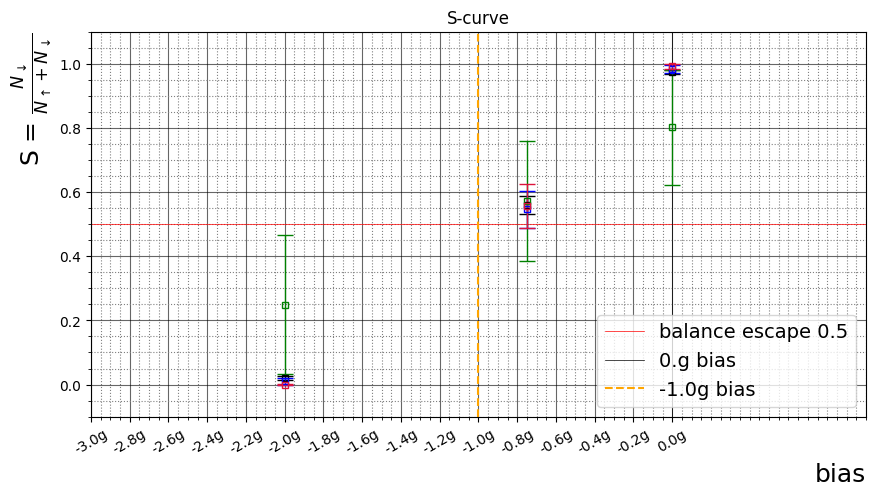

In [9]:
print("bias; S=Ndwn/(Ntot) ; dS")
for bias_, asymmetry, error in zip(bias, S, dS):
    print(f"| {bias_:.2f}g,\t  {asymmetry:.2f},\t {error:.2}")


plt.figure(1, figsize = (10, 5))
plt.title("S-curve")
plt.ylabel(r"S = $\frac{N_{\downarrow}}{N_{\uparrow} + N_{\downarrow}}$", fontsize = 18, loc = "top")
plt.xlabel("bias", loc = 'right', fontsize = 18)

plt.grid()
plt.minorticks_on()
plt.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia
plt.ylim(-0.1,1.1)
#plt.xlim(-3, 3)

#######
#plt.errorbar(biases_sim_830 - 1, simulation_830,    marker = "x", markersize = 5, linestyle = "--", color = "black", label = "sim OCT 830A")
#plt.errorbar(biases_sim_830 - 1, simulation_s6_830, marker = "x", markersize = 5, linestyle = "--", color = "green", label = "sim OCT 830A")
#plt.errorbar(biases_sim_830 - 1, simulation_s7_830, marker = "x", markersize = 5, linestyle = "--", color = "blue", label =  "sim OCT 830A")
#######

plt.axhline(0.5, linestyle = "-",  color = "red",    alpha = 1, linewidth = 0.5, label = "balance escape 0.5")
plt.axvline(0,   linestyle = "-",  color = "black",  linewidth = 0.5, label = "0.g bias")
plt.axvline(-1,  linestyle = "--", color = "orange", label = "-1.0g bias")


mask = (list_runs == "r13685")
print(mask)
plt.errorbar(bias[~mask], S[~mask], dS[~mask],             marker = "s", markersize = 4, markerfacecolor='none', color = "black", capsize = 6, elinewidth=1, linestyle = "")
plt.errorbar(bias[~mask], S_ramp1[~mask], dS_ramp1[~mask], marker = "s", markersize = 4, markerfacecolor='none', color = "green", capsize = 6, elinewidth=1, linestyle = "")
plt.errorbar(bias[~mask], S_ramp2[~mask], dS_ramp2[~mask], marker = "s", markersize = 4, markerfacecolor='none', color = "blue", capsize = 6, elinewidth=1, linestyle = "")
plt.errorbar(bias[~mask], S_ramp3[~mask], dS_ramp3[~mask], marker = "s", markersize = 4, markerfacecolor='none', color = "crimson", capsize = 6, elinewidth=1, linestyle = "")
#plt.errorbar(bias[~mask], S_ramp4[~mask], dS_ramp4[~mask], marker = "s", markersize = 4, markerfacecolor='none', color = "royalblue", capsize = 6, elinewidth=1, label = "cold", linestyle = "")
#plt.errorbar(bias[mask], S[mask], dS[mask], color="red", facecolors='none', markersize=10, marker=".", label = "mw duration lower")  # evidenzio il terzo punto



labels = np.linspace(-3,0,16)
plt.xticks(labels,[f"{item:.1f}g" for item in labels], rotation = 30)      # etichette
plt.xlim(-3,1)

# metto una etichetta vicino a ogni punto
#for xi, yi, label in zip(bias, S, list_runs):
#    plt.text(xi-0.07, yi, label, fontsize=10, ha="right", va="bottom")

texts = []
#for xi, yi, label in zip(bias, S, list_runs):
#    texts.append(plt.text(xi - 0.8, yi, label))

#adjust_text(texts, bias, S, arrowprops=dict(arrowstyle="->", color='gray'))

plt.legend(fontsize = 14, loc = "lower right")
plt.savefig("S_curve.png", bbox_inches = 'tight')

In [10]:
mirG_center = -415
mirA_center = -671
zmin = mirA_center - 200
zgap_min = mirA_center
zmax = mirG_center + 200
zgap_max = mirG_center
CutsType = "CutsType2"